In [1]:
pip install pandapower


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn pandas


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikit-learn


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import json
import numpy as np
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import sys
from sklearn.ensemble import IsolationForest
from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.datasets.windowed_dataset import build_windowed_dataset


In [5]:
import os
print(os.getcwd())

/Users/carabowes/Fourth Year CS/Individual Project/Notebooks


In [6]:
PROJECT_ROOT = Path.cwd().parent
run_dir = PROJECT_ROOT / "runs/ieee9/standard/seed_42"

X, meta, attack_mask = build_windowed_dataset(
    run_dir=run_dir,
    window_size=10,
    stride=1,
    representation="residuals",
)

print("X shape:", X.shape)
print("Num windows:", meta["num_windows"])
print("Window size:", meta["window_size"])
print("Attack mask length:", len(attack_mask))


X shape: (191, 10)
Num windows: 191
Window size: 10
Attack mask length: 200


In [7]:
X_res, meta_res, _ = build_windowed_dataset(
    run_dir,
    window_size=10,
    stride=1,
    representation="residuals",
)

X_meas, meta_meas, _ = build_windowed_dataset(
    run_dir,
    window_size=10,
    stride=1,
    representation="measurements",
)

print(X_res.shape)
print(X_meas.shape)


(191, 10)
(191, 90)


In [8]:
print("Discarded windows:", meta["discarded"])


Discarded windows: 0


In [9]:
print(X[0])

[0.03088736 0.00495093 0.03119327 0.04802907 0.04500968 0.01177353
 0.01386292 0.04299262 0.00156006 0.01359283]


In [10]:
from src.ml.detectors.isolation_forest import IsolationForestDetector

detector = IsolationForestDetector(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    threshold_quantile=95.0,
)

detector.fit(X)


In [11]:
print("Threshold tau:", detector._tau)


Threshold tau: 0.5743056666176085


In [12]:
out = detector.predict(X)

scores = out["scores"]
alarms = out["alarms"]

print(scores.shape)
print(alarms.shape)
print("Num alarms:", alarms.sum())


(191,)
(191,)
Num alarms: 10


In [13]:
out2 = detector.predict(X)

assert np.allclose(out["scores"], out2["scores"])
assert np.array_equal(out["alarms"], out2["alarms"])


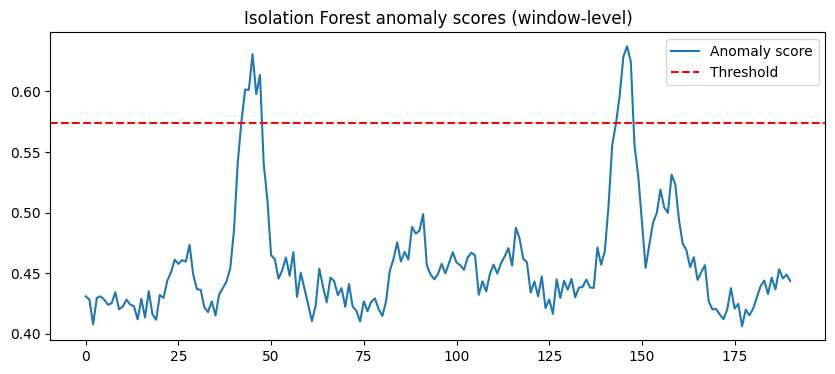

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(scores, label="Anomaly score")
plt.axhline(detector._tau, color="red", linestyle="--", label="Threshold")
plt.legend()
plt.title("Isolation Forest anomaly scores (window-level)")
plt.show()
